# Modelo Baseline — Regresión Logística

**Objetivo:** construir el modelo más simple posible de punta a punta.

Un baseline honesto responde: ¿cuánto vale nuestro modelo complejo comparado con algo trivial?
Si LightGBM no supera significativamente este baseline, hay un problema en el pipeline.

**Estrategia:**
1. Preprocesamiento mínimo pero correcto
2. Regresión Logística con `class_weight='balanced'`
3. Evaluación honesta: ROC-AUC, Precision, Recall, F1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_PATH = '../data/raw/application_train.csv'

## 1. Carga y preprocesamiento mínimo

Aplicamos exactamente lo que aprendimos en el EDA:
- Eliminar columnas con >40% de missings
- Convertir DAYS_BIRTH a edad en años
- Marcar y corregir el placeholder 365243 en DAYS_EMPLOYED
- Eliminar columnas de identificación (SK_ID_CURR)
- Encodear categóricas con Label Encoding

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape original: {df.shape}')

Shape original: (307511, 122)


In [3]:
# --- Paso 1: eliminar columnas con >40% de missings ---
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f'Columnas eliminadas por >40% missings: {len(cols_to_drop)}')
print(f'Shape tras limpieza: {df.shape}')

Columnas eliminadas por >40% missings: 49
Shape tras limpieza: (307511, 73)


In [4]:
# --- Paso 2: transformaciones desde el EDA ---

# DAYS_BIRTH → edad en años (positivo, más intuitivo)
df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365
df = df.drop(columns=['DAYS_BIRTH'])

# DAYS_EMPLOYED: 365243 es placeholder para jubilados/desempleados
# Creamos flag binario y reemplazamos con NaN para imputar luego
df['FLAG_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Eliminar ID (no tiene valor predictivo)
df = df.drop(columns=['SK_ID_CURR'])

print('Transformaciones aplicadas:')
print('  - DAYS_BIRTH → AGE_YEARS')
print('  - DAYS_EMPLOYED 365243 → NaN + FLAG_EMPLOYED_ANOMALY')
print(f'Shape: {df.shape}')

Transformaciones aplicadas:
  - DAYS_BIRTH → AGE_YEARS
  - DAYS_EMPLOYED 365243 → NaN + FLAG_EMPLOYED_ANOMALY
Shape: (307511, 73)


In [5]:
# --- Paso 3: encodear categóricas con Label Encoding ---
# Para Regresión Logística necesitamos números. 
# LightGBM (siguiente notebook) las maneja nativo, pero aquí no.

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas a encodear: {len(cat_cols)}')

for col in cat_cols:
    df[col] = pd.Categorical(df[col]).codes  # -1 para NaN automáticamente

print('Encoding completado.')
print(f'Shape final: {df.shape}')

Variables categóricas a encodear: 12
Encoding completado.
Shape final: (307511, 73)


## 2. Split train/test

Usamos `stratify=y` para garantizar que ambos splits tienen la misma proporción de TARGET=1.
Sin stratify, podría pasar que el test tenga muy pocos incumplimientos por azar.

In [6]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # importante con clases desbalanceadas
)

print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'Tasa de incumplimiento en train: {y_train.mean()*100:.2f}%')
print(f'Tasa de incumplimiento en test:  {y_test.mean()*100:.2f}%')

Train: 246,008 filas | Test: 61,503 filas
Tasa de incumplimiento en train: 8.07%
Tasa de incumplimiento en test:  8.07%


## 3. Pipeline de entrenamiento

Usamos sklearn Pipeline para encadenar preprocesamiento + modelo.
Esto evita **data leakage**: el imputer y el scaler aprenden SOLO del train,
no del test. Es un error clásico de principiantes fitear el scaler sobre todo el dataset.

`class_weight='balanced'` le dice al modelo que pese los incumplimientos
proporcionalmente a su escasez — equivalente a oversampling conceptualmente.

In [7]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # rellena NaN con la mediana
    ('scaler', StandardScaler()),                    # normaliza para regresión logística
    ('model', LogisticRegression(
        class_weight='balanced',  # compensa el desbalance 11:1
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print('Entrenando baseline...')
pipeline.fit(X_train, y_train)
print('Listo.')

Entrenando baseline...
Listo.


## 4. Evaluación — métricas honestas

**¿Por qué no usamos accuracy?**
Con 91.9% de clase 0, un modelo que siempre predice 0 tiene 91.9% de accuracy.
Eso no es un modelo, es ignorancia disfrazada de número.

**Las métricas que importan:**
- **ROC-AUC**: mide qué tan bien el modelo separa las dos clases. 0.5 = azar, 1.0 = perfecto.
- **Recall (sensibilidad)**: de todos los que incumplen, ¿cuántos detectamos?
- **Precision**: de los que predecimos como incumplimiento, ¿cuántos realmente incumplen?
- **F1**: media armónica entre precision y recall.

In [8]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print('=' * 50)
print(f'ROC-AUC: {roc_auc:.4f}')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=['No incumple', 'Incumple']))

ROC-AUC: 0.7435

              precision    recall  f1-score   support

 No incumple       0.96      0.69      0.80     56538
    Incumple       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.69      0.76     61503



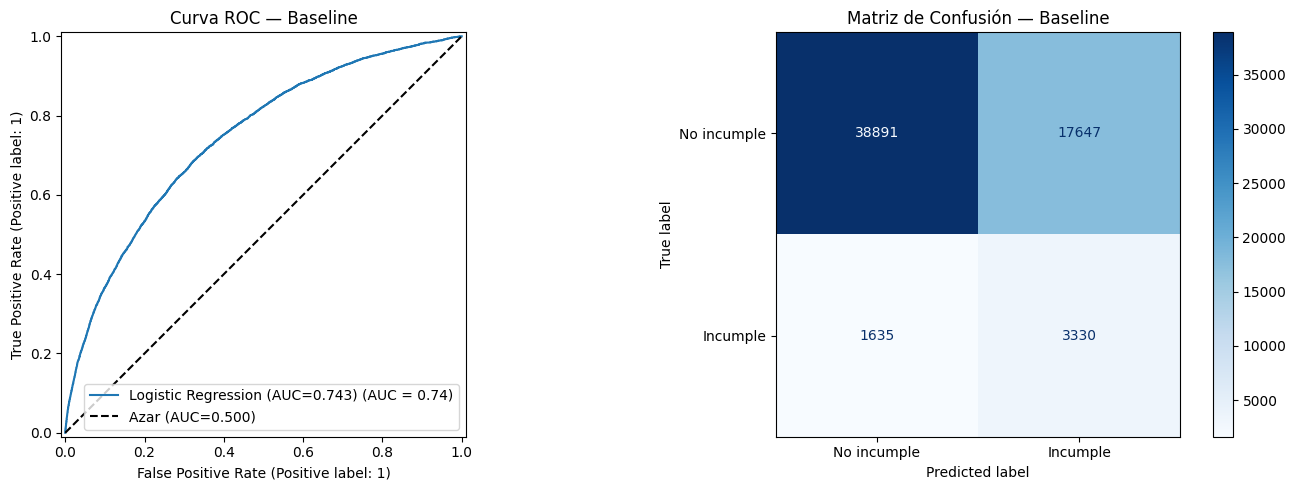

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name=f'Logistic Regression (AUC={roc_auc:.3f})',
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.500)')
axes[0].set_title('Curva ROC — Baseline')
axes[0].legend()

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No incumple', 'Incumple'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Matriz de Confusión — Baseline')

plt.tight_layout()
plt.show()

## 5. Interpretación de la matriz de confusión

La matriz tiene 4 cuadrantes:
- **Verdaderos Negativos (arriba izq):** predijo no incumple → realmente no incumplió ✓
- **Falsos Positivos (arriba der):** predijo incumplimiento → realmente pagó (rechazamos a un buen cliente)
- **Falsos Negativos (abajo izq):** predijo no incumple → realmente incumplió ✗ (el error más costoso)
- **Verdaderos Positivos (abajo der):** predijo incumplimiento → realmente incumplió ✓

In [10]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('=== Análisis de errores ===')
print(f'Verdaderos Negativos (pagaron, predijimos bien):   {tn:,}')
print(f'Falsos Positivos (pagaron, predijimos incumplimiento): {fp:,}')
print(f'Falsos Negativos (incumplieron, no los detectamos):   {fn:,}  ← el más costoso')
print(f'Verdaderos Positivos (incumplieron, detectamos):      {tp:,}')
print()
print(f'De {fn+tp:,} incumplimientos reales, detectamos {tp:,} ({tp/(fn+tp)*100:.1f}%)')
print(f'Nos escaparon {fn:,} incumplimientos ({fn/(fn+tp)*100:.1f}%)')

=== Análisis de errores ===
Verdaderos Negativos (pagaron, predijimos bien):   38,891
Falsos Positivos (pagaron, predijimos incumplimiento): 17,647
Falsos Negativos (incumplieron, no los detectamos):   1,635  ← el más costoso
Verdaderos Positivos (incumplieron, detectamos):      3,330

De 4,965 incumplimientos reales, detectamos 3,330 (67.1%)
Nos escaparon 1,635 incumplimientos (32.9%)


## 6. Resumen del baseline

Este número es nuestro **piso**. El modelo LightGBM debe superarlo.

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('=== RESUMEN BASELINE ===')
print(f'Modelo:    Regresión Logística con class_weight=balanced')
print(f'Features:  {X_train.shape[1]} columnas (tras eliminar >40% missings)')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}  (clase incumplimiento)')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}  (clase incumplimiento)')
print(f'F1:        {f1_score(y_test, y_pred):.4f}  (clase incumplimiento)')
print()
print('Este es el piso. LightGBM debe superarlo en ROC-AUC y Recall.')

=== RESUMEN BASELINE ===
Modelo:    Regresión Logística con class_weight=balanced
Features:  72 columnas (tras eliminar >40% missings)
ROC-AUC:   0.7435
Precision: 0.1587  (clase incumplimiento)
Recall:    0.6707  (clase incumplimiento)
F1:        0.2567  (clase incumplimiento)

Este es el piso. LightGBM debe superarlo en ROC-AUC y Recall.
